# Netflix Content Analysis and Visualization

In [1]:
import pandas as pd

df = pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Dataset overview

In [2]:
df.shape

(8807, 12)

In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## Data cleaning

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

### Data Cleaning

Duplicate records were removed and missing values in important columns were handled to ensure accurate visualization and analysis.

## Visualization 1: Distribution of Movies and TV Shows

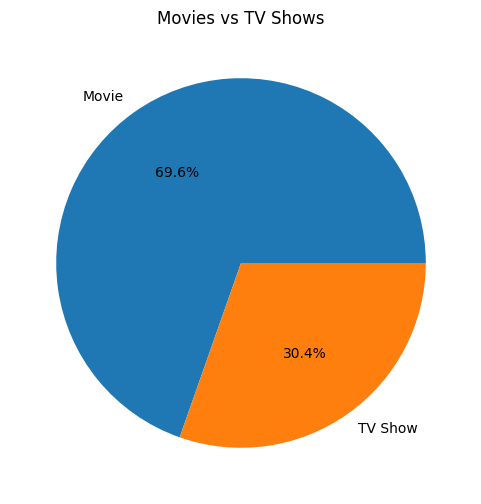

In [9]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Movies vs TV Shows')
plt.ylabel('')
plt.show()

### Insight

Movies constitute the majority of content available on Netflix, while TV Shows represent a smaller portion of the catalog. This suggests that Netflix has historically focused more on movie content.

## Visualization 2: Content Added Over Time

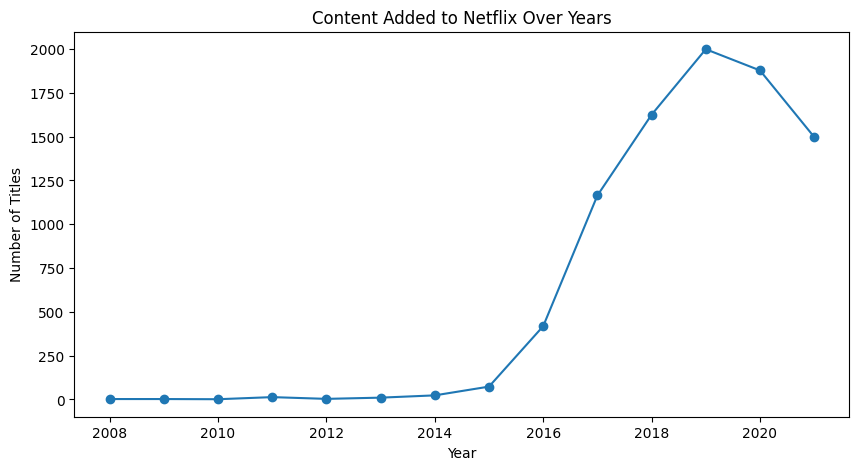

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

yearly_content = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_content.plot(kind='line', marker='o')

plt.title('Content Added to Netflix Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

### Insight

The number of titles added to Netflix increased significantly over the years, reflecting the platform's rapid expansion and investment in content acquisition.

## Visualization 3: Top Content Producing Countries

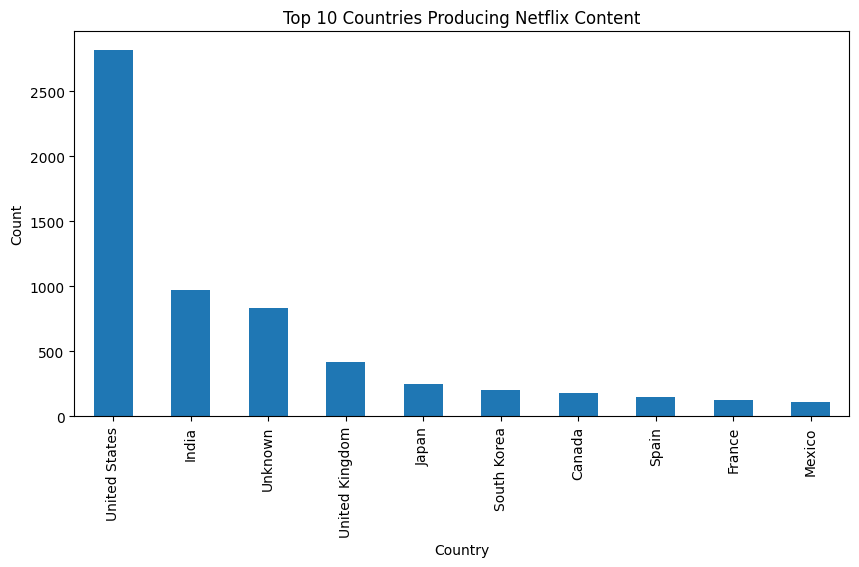

In [11]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

### Insight

The United States contributes the highest amount of content to Netflix, followed by other major content-producing countries.

## Visualization 4: Content Rating Distribution

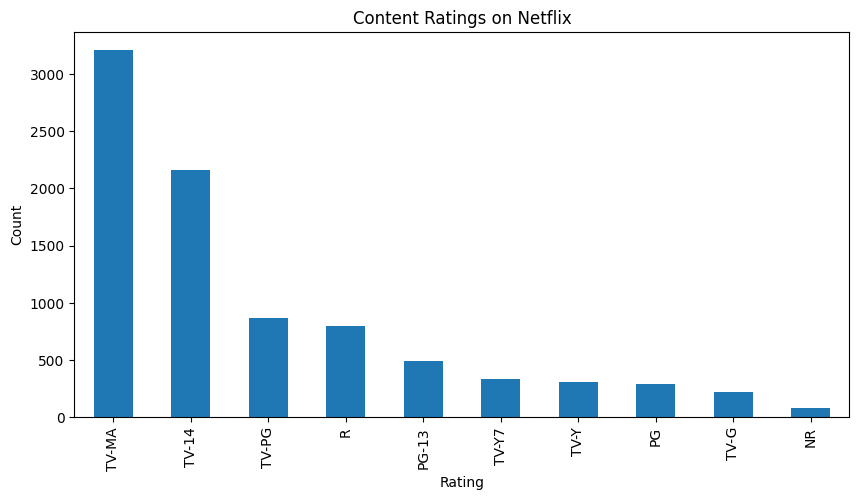

In [12]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Insight

TV-MA and TV-14 are among the most common ratings, indicating that Netflix primarily targets teenage and adult audiences.

## Visualization 5: Most Popular Genres

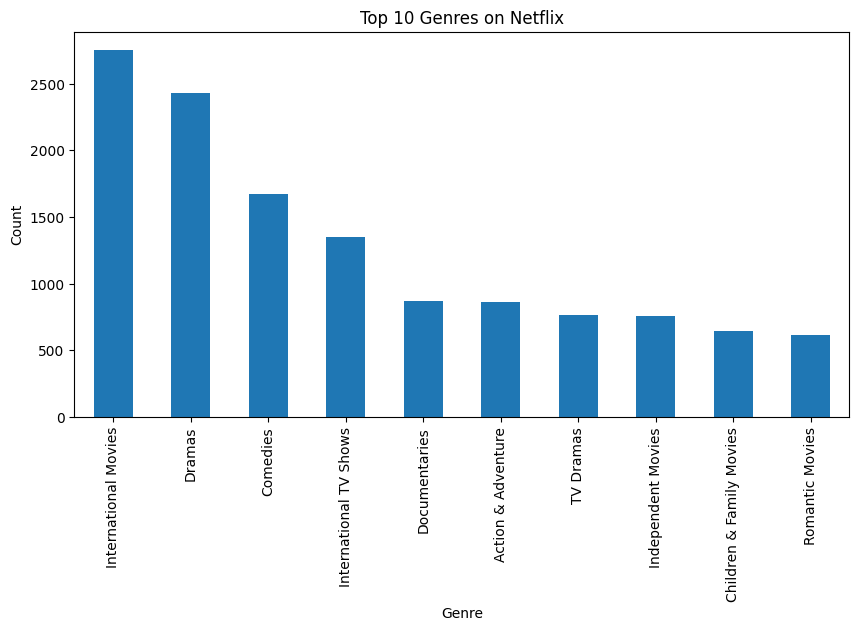

In [13]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

### Insight

Drama, International Movies, and Comedy are among the most popular genres available on Netflix.

# Conclusion

1. Movies dominate Netflix's content library.
2. Netflix experienced rapid content growth over recent years.
3. The United States contributes the largest share of content.
4. Adult-focused content ratings are most common.
5. Drama and Comedy remain highly popular genres.

These visualizations provide insights into Netflix's content strategy, audience targeting, and global content distribution.